# Darstellung von Funktionen mit mehreren Variablen


## Vertiefung


### Übersicht


1. Test-Funktion für Optimierung
2. Funktion von drei Variablen
3. Contour-Plot aus Messwerten


In [1]:
import numpy as np
import matplotlib.pyplot as plt

### 1. Test-Funktionen für Optimierung


Auf der Wikipedia-Seite ["Test-Functions for Optimization"](https://en.wikipedia.org/wiki/Test_functions_for_optimization) finden sich viele spannende Funktionen von meist zwei Variablen $x$ und $y$. Wir betrachten mal die [Ackley-Function](https://en.wikipedia.org/wiki/Ackley_function):

$$ a(x,y) = -20\exp\Big[-0.2\sqrt{0.5\left(x^2 + y^2\right)}\Big] - \exp\Big[0.5\left(\cos(2\pi x) + \cos(2\pi y)\right)\Big] + e + 20 $$

und die Himmelblau-Funktion:

$$ h(x,y) = \left(x^2 + y - 11\right)^2 + \left(x + y^2 - 7\right)^2 $$


In [2]:
def ackley(x, y):
    return (
        -20 * np.exp(-0.2 * np.sqrt(0.5 * (x**2 + y**2)))
        - np.exp(0.5 * (np.cos(2 * np.pi * x) + np.cos(2 * np.pi * y)))
        + np.exp(1)
        + 20
    )


def himmelblau(x, y):
    return (x**2 + y - 11) ** 2 + (x + y**2 - 7) ** 2

Um ein Gitternetz von über die $x$-$y$-Ebene aufzuspannen und an allen Punkten die Funktionswerte zu berechnen, verwenden wir die Funktion [`np.meshgrid`](https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html).


In [3]:
n = 200
x = np.linspace(-5, 5, n)
y = np.linspace(-5, 5, n)
X, Y = np.meshgrid(x, y)

# Z = ackley(X, Y)
Z = himmelblau(X, Y)

Höhenlinien mit [`plt.contour`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contour.html). Ausprobieren:

-   Parameter `levels=25` und höher
-   [`plt.contourf`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contourf.html) verwenden


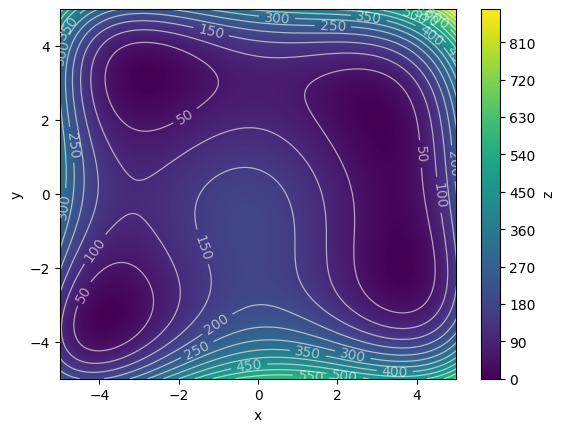

In [4]:
plt.contourf(X, Y, Z, levels=1000)
plt.colorbar(label="z")
CS = plt.contour(X, Y, Z, colors="w", levels=20, linewidths=0.9, alpha=0.6)
plt.clabel(CS)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Mit [`plt.contour`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contour.html) kann man auch mal konstante $x$ und konstante $y$ Werte anschauen. Nutze [`plt.subplots`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html), um zwei Achsenpaare nebeneinander zu machen:


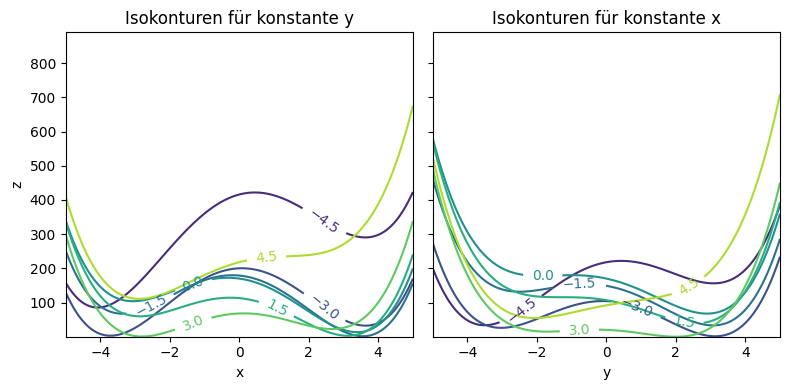

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(8, 4))
cs1 = ax1.contour(X, Z, Y)
ax1.clabel(cs1, inline=True, fontsize=10)
ax1.set_xlabel("x")
ax1.set_ylabel("z")
ax1.set_title("Isokonturen für konstante y")
cs2 = ax2.contour(Y, Z, X)
ax2.clabel(cs2, inline=True, fontsize=10)
ax2.set_xlabel("y")
ax2.set_title("Isokonturen für konstante x")
plt.tight_layout()
plt.show()

Auch Flächen im Raum sind eine Möglichkeit der Darstellung.


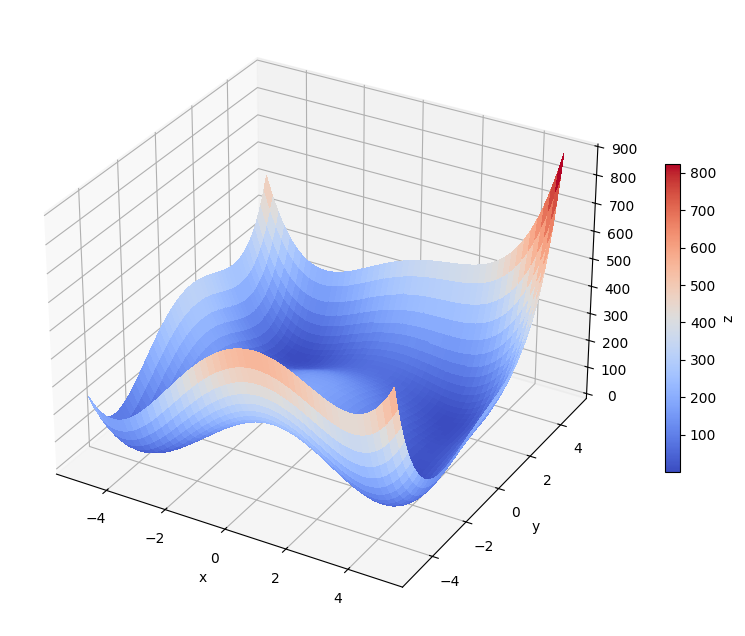

In [6]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10, 8))
surf = ax.plot_surface(X, Y, Z, cmap="coolwarm", antialiased=False)
plt.colorbar(surf, shrink=0.5, label="z")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

### 2. Funktion von drei Variablen


Wir betrachten die Funktion

$$
    f(x,y,t) = \sqrt{xy} \cdot \sin(2\pi x) \cdot \sin(2\pi t y)
$$

die von drei Variablen abhängt.

Nehmen wir an, $x$ und $y$ sind räumliche Koordinaten und $t$ ist die Zeit. Dann ist es sinnvoll, die Höhenlinien zu verschiedenen Zeiten als Funktion von $x$ und $y$ darzustellen.


In [7]:
def f(x, y, t):
    return np.sqrt(x * y) * np.sin(2 * np.pi * x) * np.sin(2 * np.pi * t * y)

Gitternetz-Punkte berechnen:


In [8]:
n = 200
x = np.linspace(0, 1, n)
y = np.linspace(0, 2, n)


X, Y = np.meshgrid(x, y)

Für jeden Zeitpunkt ein Höhenliniendiagramm darstellen:


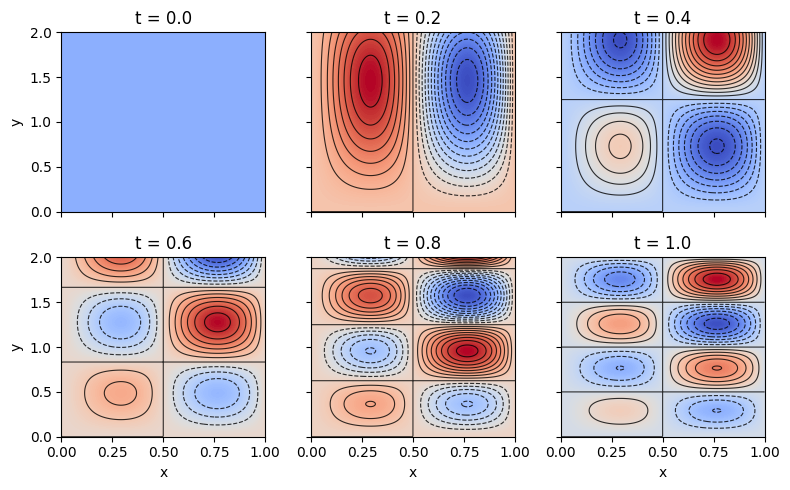

In [9]:
t_vals = np.linspace(0, 1, 6)

fig, axs = plt.subplots(2, len(t_vals) // 2, figsize=(8, 5), sharex=True, sharey=True)
for t, ax in zip(t_vals, axs.flat):
    Z = f(X, Y, t)
    ax.contourf(X, Y, Z, levels=200, cmap="coolwarm")
    ax.contour(X, Y, Z, levels=20, colors="k", linewidths=0.8, alpha=0.8)
    ax.set_title(f"t = {t:.1f}")

for ax in axs[-1, :]:
    ax.set_xlabel("x")
for ax in axs[:, 0]:
    ax.set_ylabel("y")
plt.tight_layout()
plt.show()

### 3. Contour-Plot aus Messwerten


Um Höhenlinien mit [`plt.contour`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contour.html) oder [`plt.contourf`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contourf.html) darzustellen, müssen die x-, y- und z-Werte in Form von Gitternetzen vorliegen, die normalerweise mit [`np.meshgrid`](https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html). erzeugt werden. Das ist praktisch, wenn man eine Funktion analytisch kennt und an den Gitterpunkten auswerten kann.

Hat man aber Messwerte, die nicht auf einem regelmässigen Gitter liegen, so benutzt man die Funktionen [`plt.tricontour`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.tricontour.html) bzw. [`plt.tricontourf`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.tricontourf.html). Diese verwenden Triangulation, um die Funktion zwischen den gegebenen Messpunkten zu interpolieren. (Methode nicht Thema dieses Kurses.)

Ein ausfühliches Beispiel dazu findet sich hier: [Tricontour Smooth Delaunay](https://matplotlib.org/stable/gallery/images_contours_and_fields/tricontour_smooth_delaunay.html).

Wir betrachten hier ein einfacheres Beispiel und zwar jenes aus Beispiel 2

$$
    f(x,y,t) = \sqrt{xy} \cdot \sin(2\pi x) \cdot \sin(2\pi t y)
$$

diesmal aber mit simulierten Messwerten.


In [10]:
def f(x, y, t):
    return np.sqrt(x * y) * np.sin(2 * np.pi * x) * np.sin(2 * np.pi * t * y)

Nun simulieren wir "Messwerte" dieser Funktion an `n` zufälligen Punkten im Bereich $x\in[0,1]$ und $y\in[0,2]$.


In [11]:
n = 1000
rng = np.random.default_rng(12345678)
x_data = rng.uniform(0, 1, size=n)
y_data = rng.uniform(0, 2, size=n)

t = 0.6
z_data = f(x_data, y_data, t)  # als gemessen gedachte Werte

Die Darstellung erfolgt mit `plt.tricontour`:


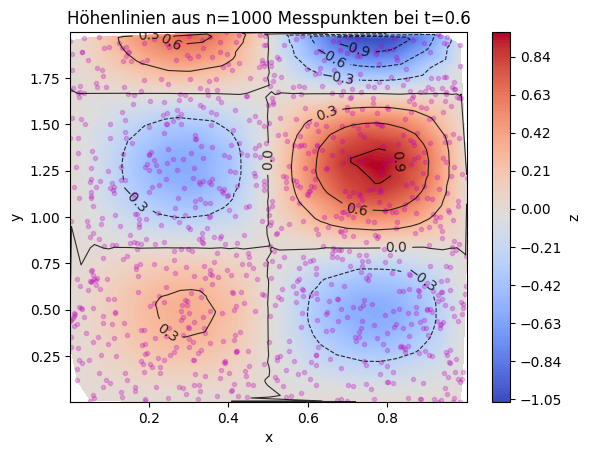

In [12]:
plt.tricontourf(x_data, y_data, z_data, levels=200, cmap="coolwarm")
plt.colorbar(label="z")
plt.scatter(x_data, y_data, color="m", marker=".", alpha=0.25)
cs = plt.tricontour(x_data, y_data, z_data, colors="k", linewidths=0.8, alpha=0.8)
plt.clabel(cs)
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Höhenlinien aus n={n} Messpunkten bei t={t}")
plt.show()